In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import ellipk, ellipe
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import Normalize

plt.style.use('custom_paper')

In [2]:
G = 1
M = 1
a,z0 = 1.0,0.1

In [3]:
def phi_ana(x0, y0, z0, a):
    r0 = np.sqrt(x0**2 + y0**2)
    R = np.sqrt(r0**2 + z0**2)
    d = np.sqrt(a**2 - 2 * a * r0 + R**2)
    k = -4 * a * r0 / (a**2 - 2 * a * r0 + R**2)
    return -((2 * G * M) / (np.pi * d)) * ellipk(k)

def az(x0, y0, z0, a):
    r0 = np.sqrt(x0**2 + y0**2)
    R = np.sqrt(r0**2 + z0**2)
    d = np.sqrt(a**2 - 2 * a * r0 + R**2)
    p = np.sqrt(a**2 + 2 * a * r0 + R**2)
    k = -4 * a * r0 / (a**2 - 2 * a * r0 + R**2)
    return -((2 * G * M) / (np.pi * p**2)) * (z0 / d) * ellipe(k)

def ar(x0, y0, z0, a):
    r0 = np.sqrt(x0**2 + y0**2)
    R = np.sqrt(r0**2 + z0**2)
    d = np.sqrt(a**2 - 2 * a * r0 + R**2)
    p = np.sqrt(a**2 + 2 * a * r0 + R**2)
    q2 = a**2 - 2 * r0**2 + R**2
    k = -4 * a * r0 / (a**2 - 2 * a * r0 + R**2)
    return (G * M) / (np.pi * r0 * d) * ((q2 / p**2) * ellipe(k) - ellipk(k))

def atheta(x0, y0, z0, a):
    return 0.0

In [4]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from functools import partial
from scipy.special import roots_legendre  # SciPy provides the Gauss–Legendre nodes



N_QUAD = 4096*4
nodes_np, weights_np = roots_legendre(N_QUAD)
thetas_np = np.pi * (nodes_np + 1.0)
wts_np = weights_np * np.pi

thetas_jax = jnp.asarray(thetas_np)
wts_jax = jnp.asarray(wts_np)

@jax.jit
def phi_num_ad_scalar(x0, y0, z0, a):
    r0 = jnp.sqrt(x0**2 + y0**2)
    theta0 = jnp.arctan2(y0, x0)
    d = jnp.sqrt(a**2 + r0**2 + z0**2 - 2.0 * a * r0 * jnp.cos(thetas_jax - theta0))
    integral = jnp.sum(wts_jax / d)
    return -(G * M) / (2.0 * jnp.pi) * integral

grad_phi_cart = jax.grad(phi_num_ad_scalar, argnums=(0, 1, 2))

@jax.jit
def accel_cyl_scalar(x0, y0, z0, a):
    gx, gy, gz = grad_phi_cart(x0, y0, z0, a)
    ax, ay, az = -gx, -gy, -gz
    r = jnp.sqrt(x0**2 + y0**2)
    ar = (x0 * ax + y0 * ay) / r
    atheta = (x0 * ay - y0 * ax) / r
    return ar, atheta, az


In [5]:
x_vals = np.linspace(-2, 2, 1000)
y_vals = np.linspace(-2, 2, 1000)
X, Y = np.meshgrid(x_vals, y_vals)

In [6]:
phi_num_vals = np.zeros_like(X)
phi_ana_vals = np.zeros_like(X)

ar_num = np.zeros_like(X)
ar_ana = np.zeros_like(X)

atheta_num = np.zeros_like(X)
atheta_ana = np.zeros_like(X)

az_num = np.zeros_like(X)
az_ana = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = X[i, j]
        y = Y[i, j]

        phi_num_vals[i, j] = float(phi_num_ad_scalar(x, y, z0, a))
        a_r, a_theta, a_z = accel_cyl_scalar(x, y, z0, a)
        ar_num[i, j] = float(a_r)
        atheta_num[i, j] = float(a_theta)
        az_num[i, j] = float(a_z)

        phi_ana_vals[i, j] = phi_ana(x, y, z0, a)
        ar_ana[i, j] = ar(x, y, z0, a)
        atheta_ana[i, j] = atheta(x, y, z0, a)
        az_ana[i, j] = az(x, y, z0, a)


/tmp/ipykernel_73871/4092659231.py:13: RuntimeWarning: divide by zero encountered in log10
  a = np.log10(np.abs(phi_num_vals - phi_ana_vals))


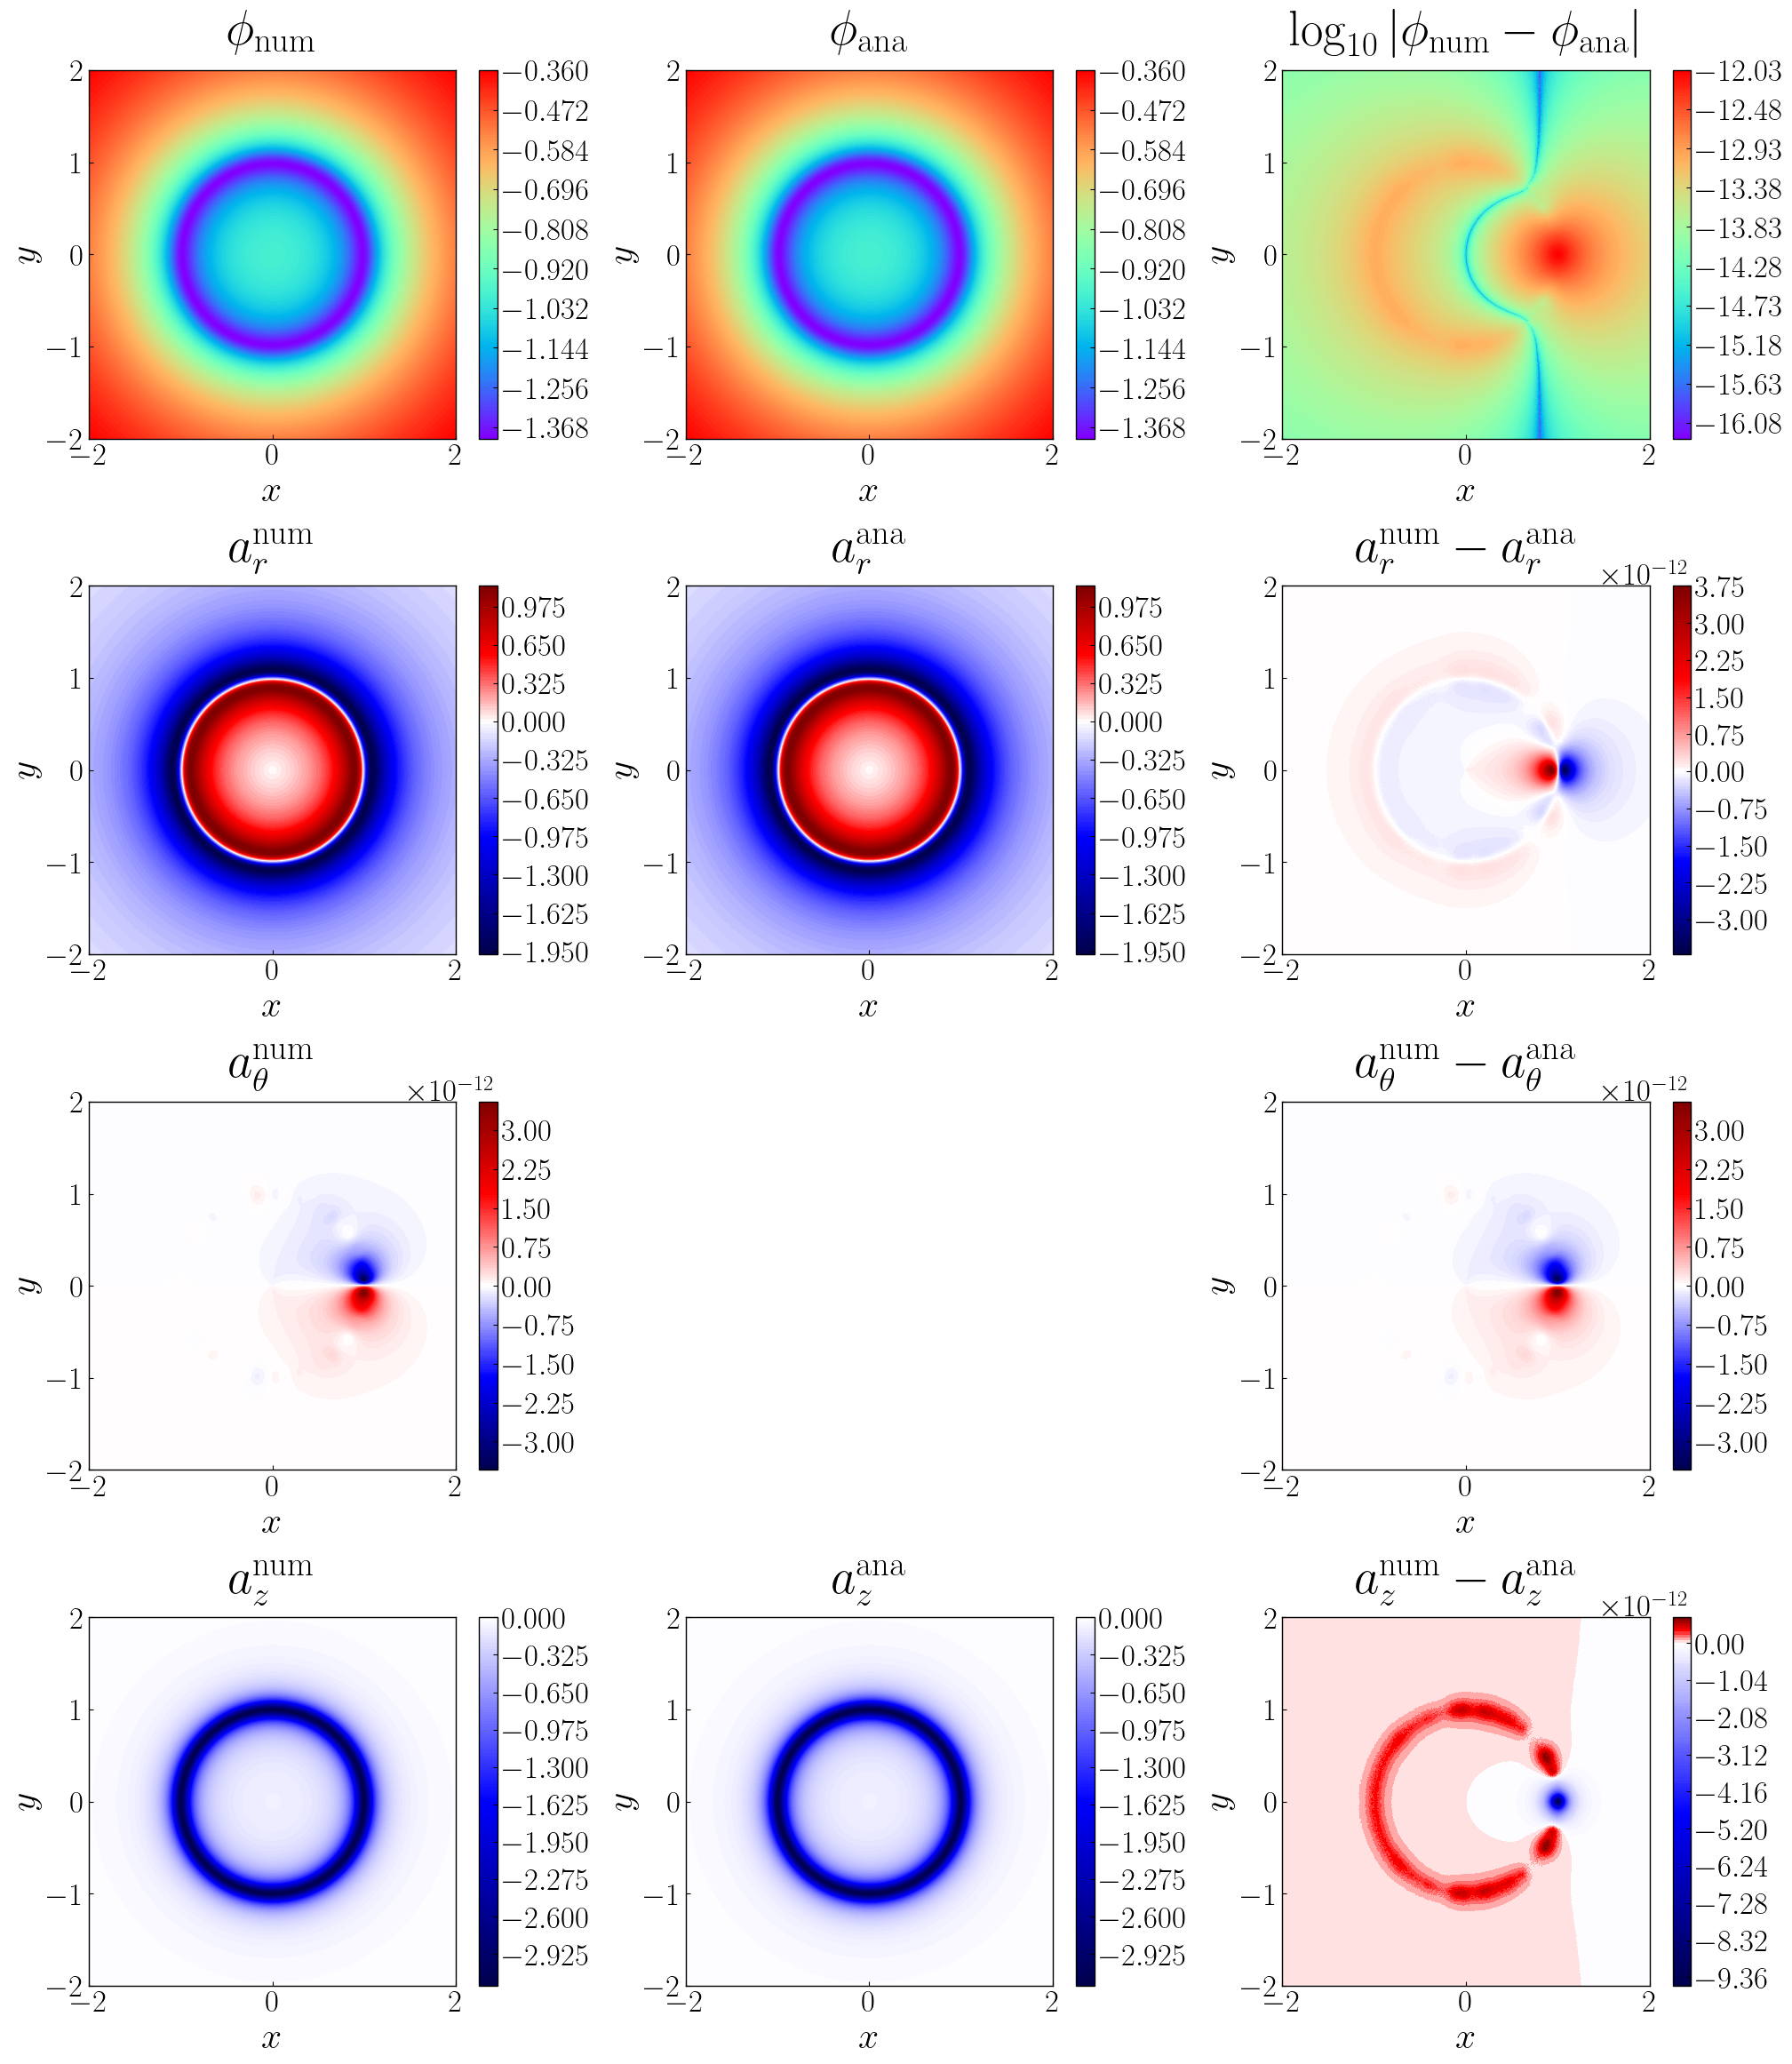

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(24, 28))
fig.subplots_adjust(wspace=0.3, hspace=0.4)

axes[0, 0].set_title(r"$\phi_{\mathrm{num}}$")
im0 = axes[0, 0].contourf(X, Y, phi_num_vals, 150, cmap='rainbow')
fig.colorbar(im0, ax=axes[0, 0])

axes[0, 1].set_title(r"$\phi_{\mathrm{ana}}$")
im1 = axes[0, 1].contourf(X, Y, phi_ana_vals, 150, cmap='rainbow')
fig.colorbar(im1, ax=axes[0, 1])

axes[0, 2].set_title(r"$\log_{10}|\phi_{\mathrm{num}} - \phi_{\mathrm{ana}}|$")
a = np.log10(np.abs(phi_num_vals - phi_ana_vals))
im2 = axes[0, 2].contourf(X, Y, a, 150, cmap='rainbow')
fig.colorbar(im2, ax=axes[0, 2])

axes[1, 0].set_title(r"$a_r^{\mathrm{num}}$")
norm_ar_num = TwoSlopeNorm(vmin=np.min(ar_num), vcenter=0, vmax=np.max(ar_num))
im3 = axes[1, 0].contourf(X, Y, ar_num, 150, cmap='seismic', norm=norm_ar_num)
fig.colorbar(im3, ax=axes[1, 0])

axes[1, 1].set_title(r"$a_r^{\mathrm{ana}}$")
norm_ar_ana = TwoSlopeNorm(vmin=np.min(ar_ana), vcenter=0, vmax=np.max(ar_ana))
im4 = axes[1, 1].contourf(X, Y, ar_ana, 150, cmap='seismic', norm=norm_ar_ana)
fig.colorbar(im4, ax=axes[1, 1])

axes[1, 2].set_title(r"$a_r^{\mathrm{num}} - a_r^{\mathrm{ana}}$")
diff_ar = ar_num - ar_ana
norm_diff_ar = TwoSlopeNorm(vmin=np.min(diff_ar), vcenter=0, vmax=np.max(diff_ar))
im5 = axes[1, 2].contourf(X, Y, diff_ar, 150, cmap='seismic', norm=norm_diff_ar)
fig.colorbar(im5, ax=axes[1, 2])

axes[2, 0].set_title(r"$a_\theta^{\mathrm{num}}$")
norm_atheta_num = TwoSlopeNorm(vmin=np.min(atheta_num), vcenter=0, vmax=np.max(atheta_num))
im6 = axes[2, 0].contourf(X, Y, atheta_num, 150, cmap='seismic', norm=norm_atheta_num)
fig.colorbar(im6, ax=axes[2, 0])

im7 = axes[2, 1].contourf(X, Y, atheta_ana, levels=[-1e-10, 1e-10], colors='white')
axes[2, 1].axis("off")



axes[2, 2].set_title(r"$a_\theta^{\mathrm{num}} - a_\theta^{\mathrm{ana}}$")
diff_atheta = atheta_num - atheta_ana
norm_diff_atheta = TwoSlopeNorm(vmin=np.min(diff_atheta), vcenter=0, vmax=np.max(diff_atheta))
im8 = axes[2, 2].contourf(X, Y, diff_atheta, 150, cmap='seismic', norm=norm_diff_atheta)
fig.colorbar(im8, ax=axes[2, 2])

axes[3, 0].set_title(r"$a_z^{\mathrm{num}}$")
norm_az_num = TwoSlopeNorm(vmin=np.min(az_num), vcenter=0, vmax=-np.min(az_num))
im9 = axes[3, 0].contourf(X, Y, az_num, 150, cmap='seismic', norm=norm_az_num)
fig.colorbar(im9, ax=axes[3, 0])

axes[3, 1].set_title(r"$a_z^{\mathrm{ana}}$")
norm_az_ana = TwoSlopeNorm(vmin=np.min(az_ana), vcenter=0, vmax=-np.min(az_ana))
im10 = axes[3, 1].contourf(X, Y, az_ana, 150, cmap='seismic', norm=norm_az_ana)
fig.colorbar(im10, ax=axes[3, 1])

axes[3, 2].set_title(r"$a_z^{\mathrm{num}} - a_z^{\mathrm{ana}}$")
diff_az = az_num - az_ana
norm_diff_az = TwoSlopeNorm(vmin=np.min(diff_az), vcenter=0, vmax=np.max(diff_az))
im11 = axes[3, 2].contourf(X, Y, diff_az, 150, cmap='seismic', norm=norm_diff_az)
fig.colorbar(im11, ax=axes[3, 2])

for i, ax in np.ndenumerate(axes):
    if i != (2, 1):  # skip a_theta^{ana}
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")

plt.savefig("circular_ring_plot.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_73871/255858089.py:13: RuntimeWarning: divide by zero encountered in log10
  a = np.log10(np.abs(phi_num_vals - phi_ana_vals))


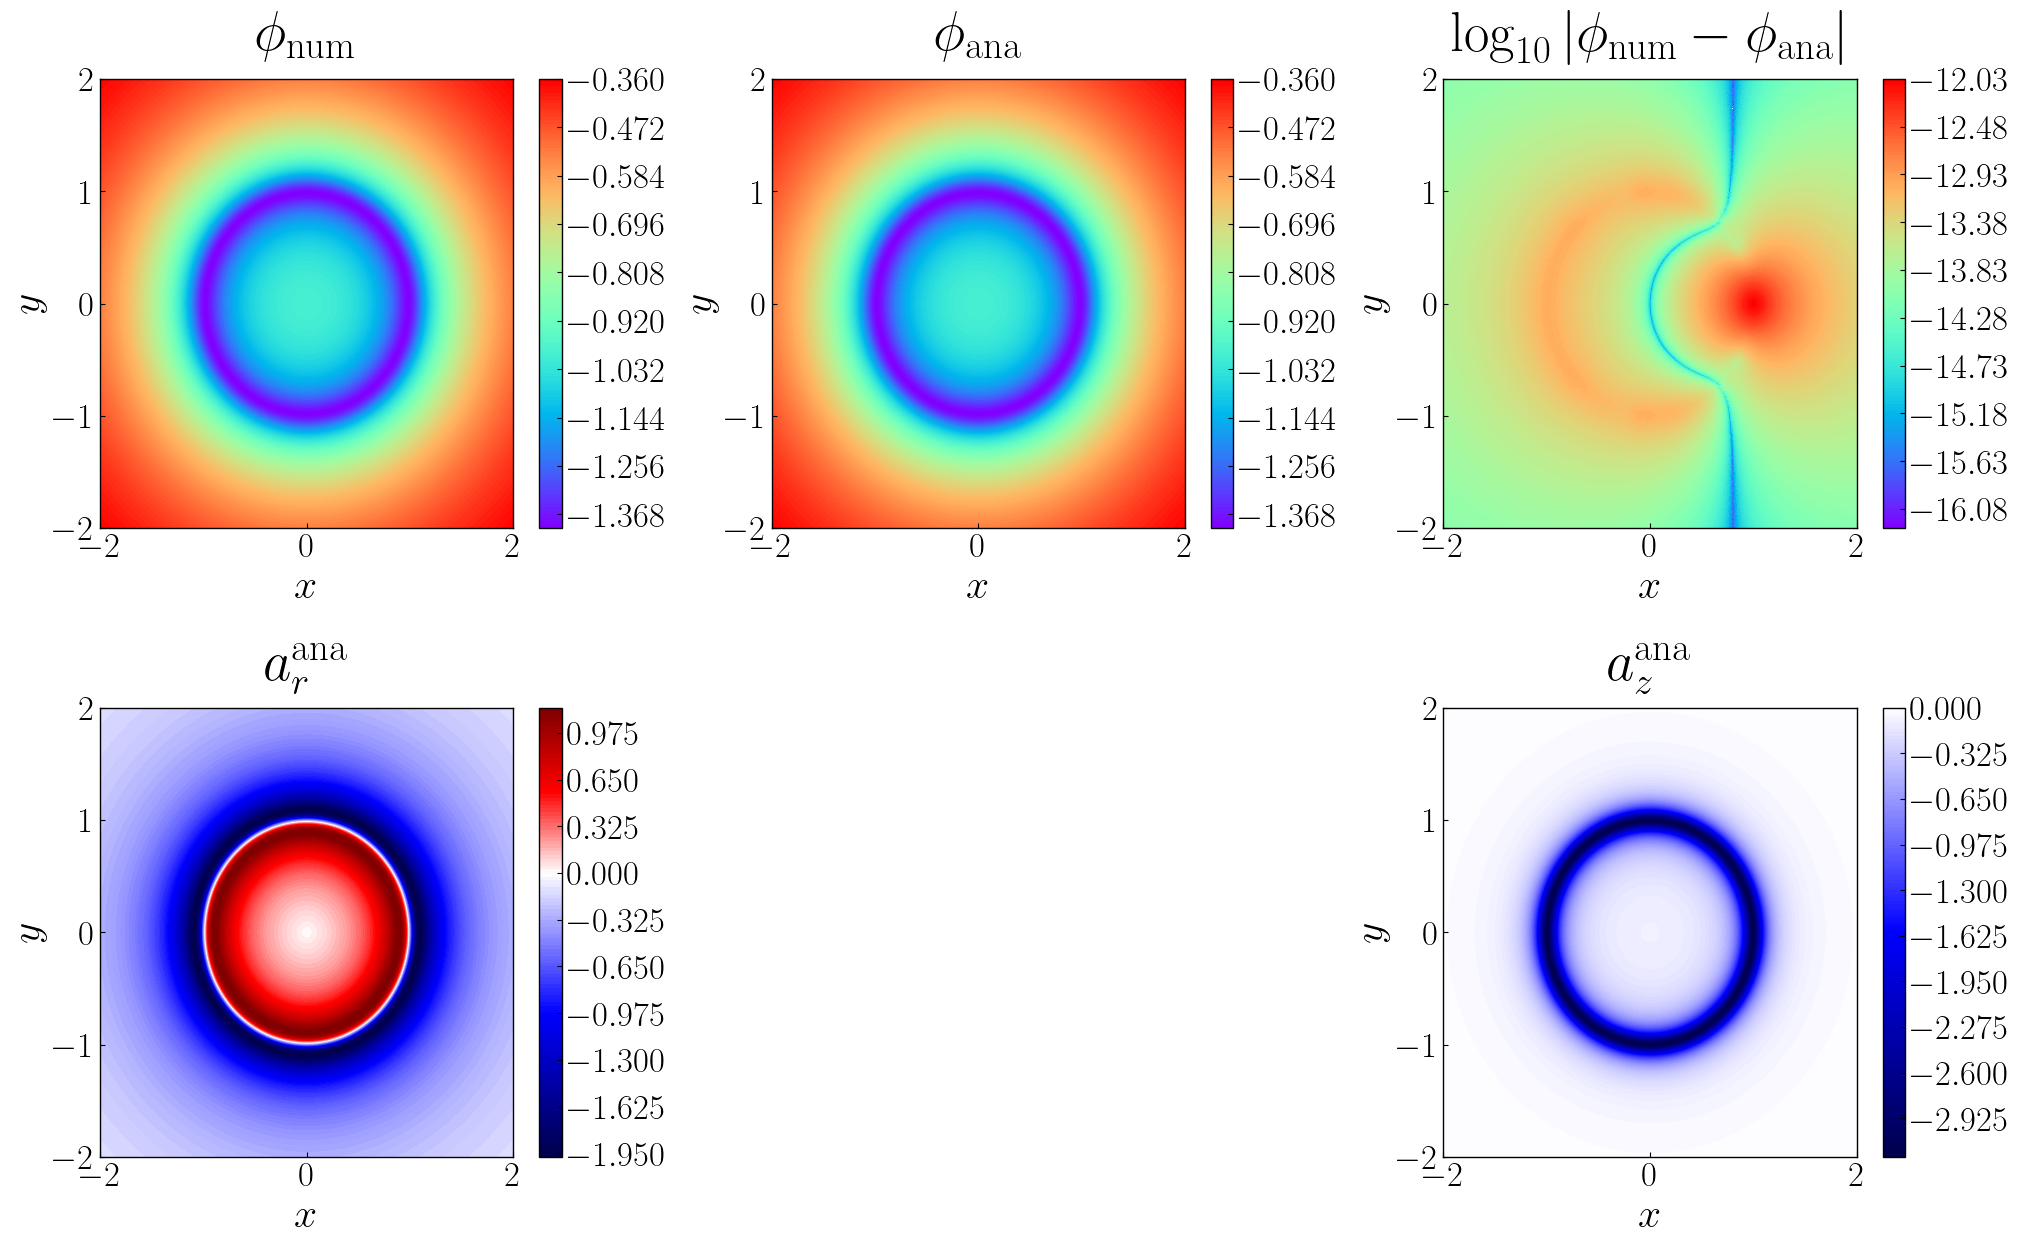

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.subplots_adjust(wspace=0.3, hspace=0.4)

axes[0, 0].set_title(r"$\phi_{\mathrm{num}}$")
im0 = axes[0, 0].contourf(X, Y, phi_num_vals, 150, cmap='rainbow')
fig.colorbar(im0, ax=axes[0, 0])

axes[0, 1].set_title(r"$\phi_{\mathrm{ana}}$")
im1 = axes[0, 1].contourf(X, Y, phi_ana_vals, 150, cmap='rainbow')
fig.colorbar(im1, ax=axes[0, 1])

axes[0, 2].set_title(r"$\log_{10}|\phi_{\mathrm{num}} - \phi_{\mathrm{ana}}|$")
a = np.log10(np.abs(phi_num_vals - phi_ana_vals))
im2 = axes[0, 2].contourf(X, Y, a, 150, cmap='rainbow')
fig.colorbar(im2, ax=axes[0, 2])

axes[1, 0].set_title(r"$a_r^{\mathrm{ana}}$")
norm_ar_ana = TwoSlopeNorm(vmin=np.min(ar_ana), vcenter=0, vmax=np.max(ar_ana))
im3 = axes[1, 0].contourf(X, Y, ar_ana, 150, cmap='seismic', norm=norm_ar_ana)
fig.colorbar(im3, ax=axes[1, 0])

axes[1, 1].axis('off')

axes[1, 2].set_title(r"$a_z^{\mathrm{ana}}$")
norm_az_ana = TwoSlopeNorm(vmin=np.min(az_ana), vcenter=0, vmax=-np.min(az_ana))
im5 = axes[1, 2].contourf(X, Y, az_ana, 150, cmap='seismic', norm=norm_az_ana)
fig.colorbar(im5, ax=axes[1, 2])

for ax in (axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,2]):
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

plt.savefig("circular_ring_plot2.png", dpi=300, bbox_inches="tight")
plt.show()
